**1. Dijkstra's Algorithm**

In [3]:
import pandas as pd
import numpy as np
import heapq
import matplotlib.pyplot as plt

In [4]:
distances = pd.read_csv("Distances.csv", index_col=0)
lat_long = pd.read_csv("Lat_Long.csv")

print("Distance Dataset:")
display(distances.head())

print("\nLatitude and Longitude Dataset:")
display(lat_long.head())

Distance Dataset:


,Kolapur,Ahmedabad,Vellore,Agra,Cuttack,Guwahati,Kolkata,Aligarh,Madurai,Raipur,...,Delhi,Gwalior,Solapur,Bangalore,Bikaner,Ghaziabad,Rajkot,Lucknow,Dwarka,Mumbai
Kolapur,100000.000,137.513,1454.366,737.237,1517.434,2045.019,1718.420,787.430,1690.350,1070.345,...,762.516,706.893,769.650,1362.334,486.823,788.614,195.305,991.731,327.281,563.090
Ahmedabad,137.513,100000.000,1320.030,715.165,1403.936,1971.163,1620.624,775.508,1563.090,954.543,...,772.896,665.641,637.919,1231.355,558.213,796.692,199.104,943.527,380.411,452.822
Vellore,1454.366,1320.030,100000.000,1595.387,1121.923,1994.073,1467.862,1672.211,351.499,975.470,...,1763.191,1487.015,687.538,154.314,1785.731,1769.621,1364.952,1567.737,1491.432,947.486
Agra,737.237,715.165,1595.387,100000.000,1092.406,1371.776,1163.269,78.774,1919.719,753.526,...,180.843,108.641,1070.167,1572.254,472.531,179.075,906.589,292.669,1064.295,1054.728
Cuttack,1517.434,1403.936,1121.923,1092.406,100000.000,872.170,347.177,1136.081,1459.441,449.956,...,1261.993,1012.955,1152.092,1211.035,1523.690,1249.453,1575.895,867.006,1763.468,1377.594



Latitude and Longitude Dataset:


,Unnamed: 0,City,Latitude,Longitude
0,0,Kolapur,23.896495,71.624653
1,1,Ahmedabad,23.021624,72.579707
2,2,Vellore,12.794811,79.000641
3,3,Agra,27.175255,78.009816
4,4,Cuttack,20.468600,85.879200


In [5]:
print("Number of cities:", len(distances))

print("\nDistance matrix shape:", distances.shape)

print("\nCity names:")
print(distances.columns.tolist())

Number of cities: 50

Distance matrix shape: (50, 50)

City names:
['Kolapur', 'Ahmedabad', 'Vellore', 'Agra', 'Cuttack', 'Guwahati', 'Kolkata', 'Aligarh', 'Madurai', 'Raipur', 'Thiruvananthapuram', 'Jhansi', 'Patiala', 'Visakhapatnam', 'Kota', 'Jaipur', 'Jammu', 'Goa', 'Chennai', 'Varanasi', 'Vadodara', 'Jamshedpur', 'Aurangabad', 'Jabalpur', 'Leh', 'Gandhinagar', 'Jaisalmer', 'Chandigarh', 'Hyderabad', 'Nashik', 'Ranchi', 'Pune', 'Jodhpur', 'Indore', 'Jalgaon', 'Nanded', 'Gangtok', 'Bhopal', 'Patna', 'Srinagar', 'Delhi', 'Gwalior', 'Solapur', 'Bangalore', 'Bikaner', 'Ghaziabad', 'Rajkot', 'Lucknow', 'Dwarka', 'Mumbai']


In [6]:
# Remove extra spaces from city names
distances.index = distances.index.astype(str).str.strip()
distances.columns = distances.columns.astype(str).str.strip()

# Convert values to numbers
distances = distances.apply(pd.to_numeric, errors='coerce')

# Distance from a city to itself is 0
for city in distances.index:
    distances.loc[city, city] = 0

display(distances.head())

,Kolapur,Ahmedabad,Vellore,Agra,Cuttack,Guwahati,Kolkata,Aligarh,Madurai,Raipur,...,Delhi,Gwalior,Solapur,Bangalore,Bikaner,Ghaziabad,Rajkot,Lucknow,Dwarka,Mumbai
Kolapur,0.000,137.513,1454.366,737.237,1517.434,2045.019,1718.420,787.430,1690.350,1070.345,...,762.516,706.893,769.650,1362.334,486.823,788.614,195.305,991.731,327.281,563.090
Ahmedabad,137.513,0.000,1320.030,715.165,1403.936,1971.163,1620.624,775.508,1563.090,954.543,...,772.896,665.641,637.919,1231.355,558.213,796.692,199.104,943.527,380.411,452.822
Vellore,1454.366,1320.030,0.000,1595.387,1121.923,1994.073,1467.862,1672.211,351.499,975.470,...,1763.191,1487.015,687.538,154.314,1785.731,1769.621,1364.952,1567.737,1491.432,947.486
Agra,737.237,715.165,1595.387,0.000,1092.406,1371.776,1163.269,78.774,1919.719,753.526,...,180.843,108.641,1070.167,1572.254,472.531,179.075,906.589,292.669,1064.295,1054.728
Cuttack,1517.434,1403.936,1121.923,1092.406,0.000,872.170,347.177,1136.081,1459.441,449.956,...,1261.993,1012.955,1152.092,1211.035,1523.690,1249.453,1575.895,867.006,1763.468,1377.594


In [8]:
graph = {}

for city in distances.index:
    graph[city] = {}

    for neighbour in distances.columns:
        distance = distances.loc[city, neighbour]

        if city != neighbour and pd.notna(distance) and distance > 0:
            graph[city][neighbour] = float(distance)

print("Number of nodes:", len(graph))

Number of nodes: 50


In [9]:
print("Connections from Delhi:")
print(graph["Delhi"])

Connections from Delhi:
{'Kolapur': 762.516, 'Ahmedabad': 772.896, 'Vellore': 1763.191, 'Agra': 180.843, 'Cuttack': 1261.993, 'Guwahati': 1466.407, 'Kolkata': 1308.141, 'Aligarh': 126.073, 'Madurai': 2081.701, 'Raipur': 934.162, 'Thiruvananthapuram': 2225.492, 'Jhansi': 373.202, 'Patiala': 193.009, 'Visakhapatnam': 1360.283, 'Kota': 397.499, 'Jaipur': 231.729, 'Jammu': 504.807, 'Goa': 1509.545, 'Chennai': 1751.332, 'Varanasi': 684.429, 'Vadodara': 807.138, 'Jamshedpur': 1111.996, 'Aurangabad': 986.846, 'Jabalpur': 666.457, 'Leh': 615.157, 'Gandhinagar': 750.625, 'Jaisalmer': 654.201, 'Chandigarh': 235.216, 'Hyderabad': 1251.602, 'Nashik': 1014.021, 'Ranchi': 1002.289, 'Pune': 1169.18, 'Jodhpur': 483.554, 'Indore': 667.339, 'Jalgaon': 878.109, 'Nanded': 1047.272, 'Gangtok': 1134.248, 'Bhopal': 595.255, 'Patna': 856.15, 'Srinagar': 644.022, 'Gwalior': 285.703, 'Solapur': 1209.19, 'Bangalore': 1733.117, 'Bikaner': 384.017, 'Ghaziabad': 28.242, 'Rajkot': 948.671, 'Lucknow': 420.656, 'Dwark

In [10]:
def dijkstra(graph, source):

    # Distance from source to every city
    distance = {}

    # Previous city used to reach each city
    previous = {}

    # Initialize distances
    for city in graph:
        distance[city] = float('inf')
        previous[city] = None

    # Distance from source to itself
    distance[source] = 0

    # Priority queue
    priority_queue = [(0, source)]

    while priority_queue:

        # Get city with minimum distance
        current_distance, current_city = heapq.heappop(priority_queue)

        # Ignore outdated values
        if current_distance > distance[current_city]:
            continue

        # Check all neighbouring cities
        for neighbour, edge_weight in graph[current_city].items():

            new_distance = current_distance + edge_weight

            # If a shorter path is found
            if new_distance < distance[neighbour]:

                distance[neighbour] = new_distance
                previous[neighbour] = current_city

                heapq.heappush(
                    priority_queue,
                    (new_distance, neighbour)
                )

    return distance, previous

In [11]:
def get_path(previous, source, destination):

    path = []

    current = destination

    while current is not None:

        path.append(current)

        if current == source:
            break

        current = previous[current]

    # If source was never reached
    if path[-1] != source:
        return []

    path.reverse()

    return path


In [12]:
source_city = "Delhi"

shortest_distances, previous = dijkstra(
    graph,
    source_city
)

print("Source city:", source_city)

Source city: Delhi


In [13]:
results = []

for city in shortest_distances:

    path = get_path(
        previous,
        source_city,
        city
    )

    results.append({
        "Source": source_city,
        "Destination": city,
        "Shortest Distance (km)": round(shortest_distances[city], 2),
        "Shortest Path": " -> ".join(path)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Shortest Distance (km)"
).reset_index(drop=True)

display(results_df)

,Source,Destination,Shortest Distance (km),Shortest Path
0,Delhi,Delhi,0.00,Delhi
1,Delhi,Ghaziabad,28.24,Delhi -> Ghaziabad
2,Delhi,Aligarh,126.07,Delhi -> Aligarh
3,Delhi,Agra,180.84,Delhi -> Agra
4,Delhi,Patiala,193.01,Delhi -> Patiala
5,Delhi,Jaipur,231.73,Delhi -> Jaipur
6,Delhi,Chandigarh,235.22,Delhi -> Chandigarh
7,Delhi,Gwalior,285.70,Delhi -> Gwalior
8,Delhi,Jhansi,373.20,Delhi -> Jhansi
9,Delhi,Bikaner,384.02,Delhi -> Bikaner


In [14]:
destination_city = "Mumbai"

path = get_path(
    previous,
    source_city,
    destination_city
)

distance = shortest_distances[destination_city]

print("Source:", source_city)
print("Destination:", destination_city)
print("Shortest Distance:", round(distance, 2), "km")
print("Shortest Path:")
print(" -> ".join(path))

Source: Delhi
Destination: Mumbai
Shortest Distance: 1160.21 km
Shortest Path:
Delhi -> Mumbai


In [15]:
print("Available cities:")
print(list(graph.keys()))

Available cities:
['Kolapur', 'Ahmedabad', 'Vellore', 'Agra', 'Cuttack', 'Guwahati', 'Kolkata', 'Aligarh', 'Madurai', 'Raipur', 'Thiruvananthapuram', 'Jhansi', 'Patiala', 'Visakhapatnam', 'Kota', 'Jaipur', 'Jammu', 'Goa', 'Chennai', 'Varanasi', 'Vadodara', 'Jamshedpur', 'Aurangabad', 'Jabalpur', 'Leh', 'Gandhinagar', 'Jaisalmer', 'Chandigarh', 'Hyderabad', 'Nashik', 'Ranchi', 'Pune', 'Jodhpur', 'Indore', 'Jalgaon', 'Nanded', 'Gangtok', 'Bhopal', 'Patna', 'Srinagar', 'Delhi', 'Gwalior', 'Solapur', 'Bangalore', 'Bikaner', 'Ghaziabad', 'Rajkot', 'Lucknow', 'Dwarka', 'Mumbai']


In [16]:
source_city = input("Enter source city: ")
destination_city = input("Enter destination city: ")

shortest_distances, previous = dijkstra(
    graph,
    source_city
)

path = get_path(
    previous,
    source_city,
    destination_city
)

if path:

    print("\nShortest Path:")
    print(" -> ".join(path))

    print(
        "\nShortest Distance:",
        round(shortest_distances[destination_city], 2),
        "km"
    )

else:

    print("No path found.")

Enter source city: Delhi
Enter destination city: Mumbai

Shortest Path:
Delhi -> Mumbai

Shortest Distance: 1160.21 km


In [17]:
results_df.to_csv(
    "dijkstra_results.csv",
    index=False
)

print("Results saved as dijkstra_results.csv")

Results saved as dijkstra_results.csv


In [18]:
from google.colab import files

files.download("dijkstra_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
print(lat_long.columns)

Index(['Unnamed: 0', 'City', 'Latitude', 'Longitude'], dtype='object')


In [20]:
lat_long.head()

,Unnamed: 0,City,Latitude,Longitude
0,0,Kolapur,23.896495,71.624653
1,1,Ahmedabad,23.021624,72.579707
2,2,Vellore,12.794811,79.000641
3,3,Agra,27.175255,78.009816
4,4,Cuttack,20.468600,85.879200


In [21]:
lat_long["City"] = lat_long["City"].astype(str).str.strip()

lat_long = lat_long.set_index("City")

display(lat_long.head())

,Unnamed: 0,Latitude,Longitude
City,,,
Kolapur,0,23.896495,71.624653
Ahmedabad,1,23.021624,72.579707
Vellore,2,12.794811,79.000641
Agra,3,27.175255,78.009816
Cuttack,4,20.468600,85.879200


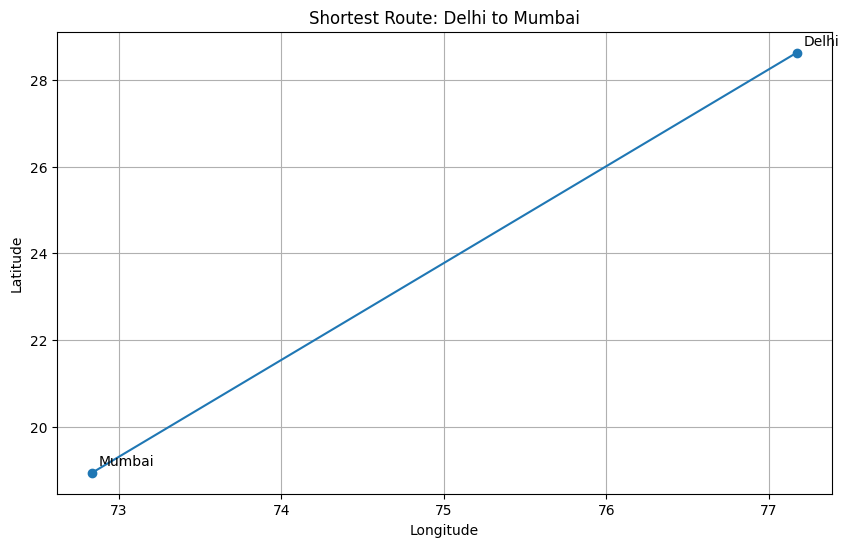

In [22]:
route_coordinates = lat_long.loc[path]

plt.figure(figsize=(10, 6))

plt.plot(
    route_coordinates["Longitude"],
    route_coordinates["Latitude"],
    marker="o"
)

for city, row in route_coordinates.iterrows():

    plt.annotate(
        city,
        (row["Longitude"], row["Latitude"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    f"Shortest Route: {source_city} to {destination_city}"
)

plt.grid(True)

plt.show()

In [23]:
source_cities = [
    "Delhi",
    "Mumbai",
    "Chennai",
    "Kolkata",
    "Hyderabad"
]

for source in source_cities:

    shortest_distances, previous = dijkstra(
        graph,
        source
    )

    print("\nSource:", source)

    for destination in ["Mumbai", "Delhi", "Chennai", "Kolkata", "Hyderabad"]:

        if destination in shortest_distances:

            print(
                destination,
                ":",
                round(shortest_distances[destination], 2),
                "km"
            )


Source: Delhi
Mumbai : 1160.21 km
Delhi : 0 km
Chennai : 1751.33 km
Kolkata : 1308.14 km
Hyderabad : 1251.6 km

Source: Mumbai
Mumbai : 0 km
Delhi : 1160.21 km
Chennai : 1027.18 km
Kolkata : 1665.43 km
Hyderabad : 619.42 km

Source: Chennai
Mumbai : 1027.18 km
Delhi : 1751.33 km
Chennai : 0 km
Kolkata : 1354.7 km
Hyderabad : 515.38 km

Source: Kolkata
Mumbai : 1665.43 km
Delhi : 1308.14 km
Chennai : 1354.7 km
Kolkata : 0 km
Hyderabad : 1184.14 km

Source: Hyderabad
Mumbai : 619.42 km
Delhi : 1251.6 km
Chennai : 515.38 km
Kolkata : 1184.14 km
Hyderabad : 0 km


Dijkstra's Algorithm Complexity

Using a binary min-heap priority queue:

Time Complexity  : O((V + E) log V)

Space Complexity : O(V + E)

Where:
V = number of vertices (cities)

E = number of edges (road connections)